In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
#import os

In [18]:
#  style for charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


pd.set_option('display.max_columns', None)

In [19]:
#print(os.listdir('../dataset/raw'))
df=pd.read_csv('./dataset/ott_dataset.csv')


In [20]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33171 entries, 0 to 33170
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   show_id               33171 non-null  int64  
 1   title                 33171 non-null  object 
 2   platform              33171 non-null  object 
 3   genre                 33171 non-null  object 
 4   release_year          33171 non-null  float64
 5   season_number         33171 non-null  int64  
 6   episode_number        33171 non-null  int64  
 7   episode_duration_min  33171 non-null  int64  
 8   pacing_score          33171 non-null  int64  
 9   hook_strength         33171 non-null  int64  
 10  dialogue_density      33171 non-null  object 
 11  visual_intensity      33171 non-null  int64  
 12  avg_watch_percentage  33171 non-null  int64  
 13  pause_count           33171 non-null  int64  
 14  rewind_count          33171 non-null  int64  
 15  skip_intro         

we can conclude that there are no null values we may not need to drop any values.

In [21]:
# checking for placeholders in objects 
# Check unique values for 'object' columns to see if there are placeholders
object_cols = ['dialogue_density', 'attention_required', 'retention_risk']
for col in object_cols:
    print(f"Unique values in {col}:", df[col].unique())

Unique values in dialogue_density: ['high' 'low' 'medium']
Unique values in attention_required: ['high' 'medium']
Unique values in retention_risk: ['high' 'medium' 'low']


We conclude there are no place holders 

Text(0.5, 1.0, 'Risk Heatmap: Impact of Pacing vs. Cognitive Load on Drop-off')

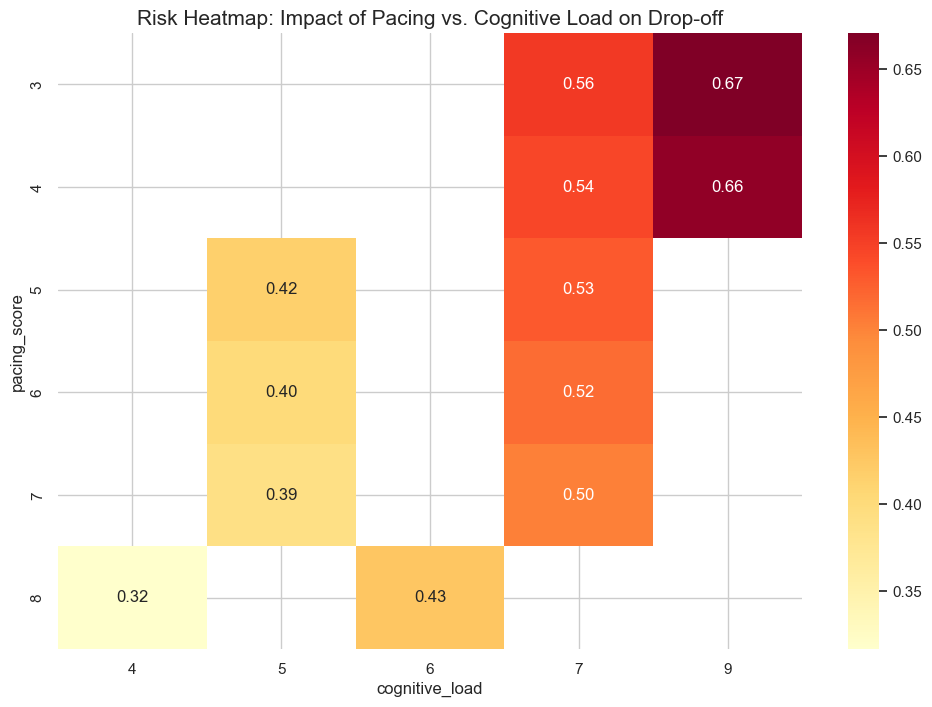

In [22]:
# we are trying to visualise which feature is affecting the drop off probability
heatmap_data = df.pivot_table(
    values='drop_off_probability', 
    index='pacing_score', 
    columns='cognitive_load', 
    aggfunc='mean'
)
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt=".2f")
plt.title('Risk Heatmap: Impact of Pacing vs. Cognitive Load on Drop-off', fontsize=15)

The drop-off probability is the highest for the complex and low-paced episodes.
Simpler and fast-paced content has much less drop-of probability.


The Danger Zone: pacing_score < 5 AND cognitive_load > 7.

The Optimal Zone: pacing_score > 6 AND cognitive_load < 6.

In [23]:
def segment_episodes(row):
    if row['pacing_score'] < 5 and row['cognitive_load'] > 7:
        return 'Complex Slow-Burn (High Risk)'
    elif row['pacing_score'] > 7 and row['cognitive_load'] < 5:
        return 'Fast Action (Low Risk)'
    else:
        return 'Balanced'

df['episode_segment'] = df.apply(segment_episodes, axis=1)

# Now, check the average drop-off for these segments
segment_analysis = df.groupby('episode_segment')['drop_off_probability'].mean()
print(segment_analysis)


episode_segment
Balanced                         0.462339
Complex Slow-Burn (High Risk)    0.659652
Fast Action (Low Risk)           0.316554
Name: drop_off_probability, dtype: float64


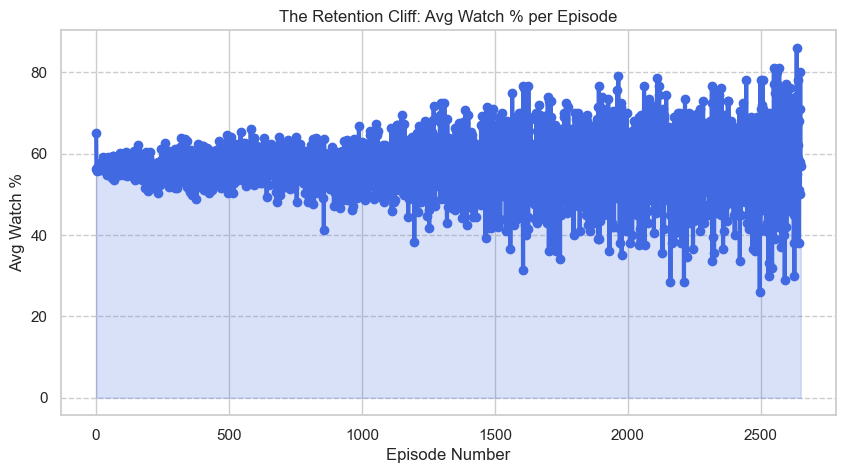

In [24]:
# Aggregate data
retention_curve = df.groupby('episode_number')['avg_watch_percentage'].mean()

plt.figure(figsize=(10, 5))
plt.plot(retention_curve.index, retention_curve.values, marker='o', color='royalblue', linewidth=3)
plt.fill_between(retention_curve.index, retention_curve.values, alpha=0.2, color='royalblue')

# Annotate the "Cliff"
plt.title('The Retention Cliff: Avg Watch % per Episode')
plt.xlabel('Episode Number')
plt.ylabel('Avg Watch %')
plt.grid(axis='y', linestyle='--')
plt.show()